In [74]:
from google.colab import files
uploaded = files.upload()

Saving ZqJlCvUi1eOaCqO1.zip to ZqJlCvUi1eOaCqO1 (1).zip


In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

## Load Dataset

In [76]:
import zipfile

# Assuming the uploaded zip file contains matches.csv and deliveries.csv
zip_file_name = next(iter(uploaded))
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall()

matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

In [77]:
print(matches.shape)

(1095, 20)


In [78]:
print(deliveries.shape)

(260920, 17)


In [79]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [80]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [81]:
matches.describe()

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


In [82]:
deliveries.describe()

,match_id,inning,over,ball,batsman_runs,extra_runs,total_runs,is_wicket
count,2.609200e+05,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000
mean,9.070665e+05,1.483531,9.197677,3.624486,1.265001,0.067806,1.332807,0.049632
std,3.679913e+05,0.502643,5.683484,1.814920,1.639298,0.343265,1.626416,0.217184
min,3.359820e+05,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483340e+05,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,9.809670e+05,1.000000,9.000000,4.000000,1.000000,0.000000,1.000000,0.000000
75%,1.254066e+06,2.000000,14.000000,5.000000,1.000000,0.000000,1.000000,0.000000
max,1.426312e+06,6.000000,19.000000,11.000000,6.000000,7.000000,7.000000,1.000000


## Check Missing Values

In [83]:
matches.isnull().sum()

,0
id,0
season,0
city,51
date,0
match_type,0
player_of_match,5
venue,0
team1,0
team2,0
toss_winner,0


In [84]:
deliveries.isnull().sum()

,0
match_id,0
inning,0
batting_team,0
bowling_team,0
over,0
ball,0
batter,0
bowler,0
non_striker,0
batsman_runs,0


## Handle Missing Values

In [85]:
city_mode_val = matches['city'].mode().get(0, 'Unknown')
matches['city'].fillna(city_mode_val, inplace=True)

player_of_match_mode_val = matches['player_of_match'].mode().get(0, 'Unknown Player')
matches['player_of_match'].fillna(player_of_match_mode_val, inplace=True)

matches['winner'].fillna("No Result", inplace=True)

matches['result_margin'].fillna(
    matches['result_margin'].median(),
    inplace=True
)

matches['target_runs'].fillna(
    matches['target_runs'].median(),
    inplace=True
)

matches['target_overs'].fillna(
    matches['target_overs'].median(),
    inplace=True
)

matches.drop(columns=['method'], inplace=True, errors='ignore')

/tmp/ipykernel_666/218586100.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  matches['city'].fillna(city_mode_val, inplace=True)
/tmp/ipykernel_666/218586100.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [86]:
deliveries['extras_type'].fillna(
    "No Extra",
    inplace=True
)

deliveries['player_dismissed'].fillna(
    "Not Out",
    inplace=True
)

deliveries['dismissal_kind'].fillna(
    "Not Dismissed",
    inplace=True
)

deliveries['fielder'].fillna(
    "No Fielder",
    inplace=True
)

/tmp/ipykernel_666/893244823.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  deliveries['extras_type'].fillna(
/tmp/ipykernel_666/893244823.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({c

In [87]:
matches.isnull().sum()

,0
id,0
season,0
city,0
date,0
match_type,0
player_of_match,0
venue,0
team1,0
team2,0
toss_winner,0


In [88]:
matches.drop(columns=['result_margin','target_runs','target_overs'],inplace=True)

In [89]:
matches.isnull().sum()

,0
id,0
season,0
city,0
date,0
match_type,0
player_of_match,0
venue,0
team1,0
team2,0
toss_winner,0


In [90]:
deliveries.isnull().sum()

,0
match_id,0
inning,0
batting_team,0
bowling_team,0
over,0
ball,0
batter,0
bowler,0
non_striker,0
batsman_runs,0


## Remove Duplicates

In [91]:
matches.drop_duplicates(inplace=True)
print(matches.columns)

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'super_over', 'umpire1', 'umpire2'],
      dtype='object')


In [92]:
deliveries.drop_duplicates(inplace=True)
print(deliveries.columns)

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')


## Check Outliers

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

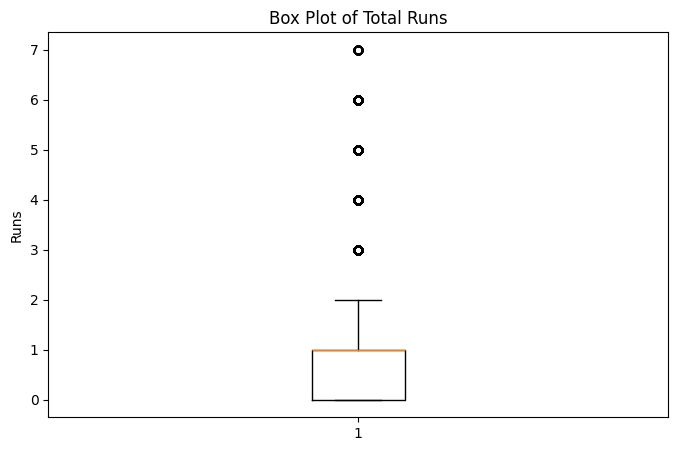

In [94]:
plt.figure(figsize=(8,5))
plt.boxplot(deliveries['total_runs'])
plt.title("Box Plot of Total Runs")
plt.ylabel("Runs")
plt.show()

In [95]:
Q1 = deliveries['total_runs'].quantile(0.25)
Q3 = deliveries['total_runs'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = deliveries[
    (deliveries['total_runs'] < lower_bound) |
    (deliveries['total_runs'] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 44719


In [96]:
Q1 = deliveries['extra_runs'].quantile(0.25)
Q3 = deliveries['extra_runs'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = deliveries[
    (deliveries['extra_runs'] < lower_bound) |
    (deliveries['extra_runs'] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 14125


## Final Validation

In [97]:
matches.info()
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               1095 non-null   int64 
 1   season           1095 non-null   object
 2   city             1095 non-null   object
 3   date             1095 non-null   object
 4   match_type       1095 non-null   object
 5   player_of_match  1095 non-null   object
 6   venue            1095 non-null   object
 7   team1            1095 non-null   object
 8   team2            1095 non-null   object
 9   toss_winner      1095 non-null   object
 10  toss_decision    1095 non-null   object
 11  winner           1095 non-null   object
 12  result           1095 non-null   object
 13  super_over       1095 non-null   object
 14  umpire1          1095 non-null   object
 15  umpire2          1095 non-null   object
dtypes: int64(1), object(15)
memory usage: 137.0+ KB
<class 'pandas.core.frame.Data

In [98]:
matches.describe()

,id
count,1.095000e+03
mean,9.048283e+05
std,3.677402e+05
min,3.359820e+05
25%,5.483315e+05
50%,9.809610e+05
75%,1.254062e+06
max,1.426312e+06


In [99]:
deliveries.describe()

,match_id,inning,over,ball,batsman_runs,extra_runs,total_runs,is_wicket
count,2.609200e+05,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000
mean,9.070665e+05,1.483531,9.197677,3.624486,1.265001,0.067806,1.332807,0.049632
std,3.679913e+05,0.502643,5.683484,1.814920,1.639298,0.343265,1.626416,0.217184
min,3.359820e+05,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483340e+05,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,9.809670e+05,1.000000,9.000000,4.000000,1.000000,0.000000,1.000000,0.000000
75%,1.254066e+06,2.000000,14.000000,5.000000,1.000000,0.000000,1.000000,0.000000
max,1.426312e+06,6.000000,19.000000,11.000000,6.000000,7.000000,7.000000,1.000000


## Create SQL Database

In [100]:
conn = sqlite3.connect("ipl.db")

## Load Tables into SQL

In [101]:
matches.to_sql("matches",conn,if_exists="replace",index=False)

1095

In [102]:
deliveries.to_sql("deliveries",conn,if_exists="replace",index=False)

260920

## SQL Queries

#### Query 1: WHERE

In [103]:
query = """SELECT * FROM matches WHERE season = 2019;"""
df_2019_matches = pd.read_sql(query, conn)
print(df_2019_matches.head())

        id season     city        date match_type  player_of_match  \
0  1175356   2019  Chennai  2019-03-23     League  Harbhajan Singh   
1  1175357   2019  Kolkata  2019-03-24     League       AD Russell   
2  1175358   2019   Mumbai  2019-03-24     League          RR Pant   
3  1175359   2019   Jaipur  2019-03-25     League         CH Gayle   
4  1175360   2019    Delhi  2019-03-26     League        SR Watson   

                    venue                        team1                  team2  \
0  MA Chidambaram Stadium  Royal Challengers Bangalore    Chennai Super Kings   
1            Eden Gardens          Sunrisers Hyderabad  Kolkata Knight Riders   
2        Wankhede Stadium               Delhi Capitals         Mumbai Indians   
3  Sawai Mansingh Stadium              Kings XI Punjab       Rajasthan Royals   
4    Arun Jaitley Stadium               Delhi Capitals    Chennai Super Kings   

             toss_winner toss_decision                 winner   result  \
0    Chennai Super

#### Query2: GROUP BY

In [104]:
query = """SELECT winner, COUNT(*) AS wins FROM matches GROUP BY winner;"""
df_winner_wins = pd.read_sql(query, conn)
print(df_winner_wins.head())

                winner  wins
0  Chennai Super Kings   138
1      Deccan Chargers    29
2       Delhi Capitals    48
3     Delhi Daredevils    67
4        Gujarat Lions    13


#### Query 3: HAVING

In [105]:
query = """SELECT winner, COUNT(*) AS wins FROM matches GROUP BY winner HAVING wins > 20;"""
df_winner_wins = pd.read_sql(query, conn)
print(df_winner_wins.head())

                winner  wins
0  Chennai Super Kings   138
1      Deccan Chargers    29
2       Delhi Capitals    48
3     Delhi Daredevils    67
4       Gujarat Titans    28


#### Query 4: ORDER BY + LIMIT

In [106]:
query = """SELECT batter, SUM(batsman_runs) AS runs FROM deliveries GROUP BY batter ORDER BY runs DESC LIMIT 10;"""
df_top_batsman = pd.read_sql(query, conn)
print(df_top_batsman)

           batter  runs
0         V Kohli  8014
1        S Dhawan  6769
2       RG Sharma  6630
3       DA Warner  6567
4        SK Raina  5536
5        MS Dhoni  5243
6  AB de Villiers  5181
7        CH Gayle  4997
8      RV Uthappa  4954
9      KD Karthik  4843


#### Query 5: BETWEEN

In [107]:
query = """SELECT * FROM matches WHERE season BETWEEN 2015 AND 2017;"""
df_matches_between_2015_2017 = pd.read_sql(query, conn)
print(df_matches_between_2015_2017.head())

       id season     city        date match_type player_of_match  \
0  829705   2015  Kolkata  2015-04-08     League        M Morkel   
1  829707   2015  Chennai  2015-04-09     League         A Nehra   
2  829709   2015     Pune  2015-04-10     League     JP Faulkner   
3  829711   2015  Chennai  2015-04-11     League     BB McCullum   
4  829713   2015  Kolkata  2015-04-11     League        CH Gayle   

                                     venue                  team1  \
0                             Eden Gardens  Kolkata Knight Riders   
1          MA Chidambaram Stadium, Chepauk    Chennai Super Kings   
2  Maharashtra Cricket Association Stadium        Kings XI Punjab   
3          MA Chidambaram Stadium, Chepauk    Chennai Super Kings   
4                             Eden Gardens  Kolkata Knight Riders   

                         team2                  toss_winner toss_decision  \
0               Mumbai Indians        Kolkata Knight Riders         field   
1             Delhi Da

#### Query 6: JOIN

In [108]:
query = """SELECT m.season, m.winner,
 SUM(d.total_runs)
 AS total_runs
  FROM matches m
  JOIN deliveries d
  ON m.id = d.match_id
  GROUP BY m.season, m.winner;"""
df_season_winner_runs = pd.read_sql(query, conn)
print(df_season_winner_runs.head())

    season                 winner  total_runs
0  2007/08    Chennai Super Kings        2945
1  2007/08        Deccan Chargers         601
2  2007/08       Delhi Daredevils        2302
3  2007/08        Kings XI Punjab        3179
4  2007/08  Kolkata Knight Riders        1756


### Create Visualizations

#### 1.Boxplot

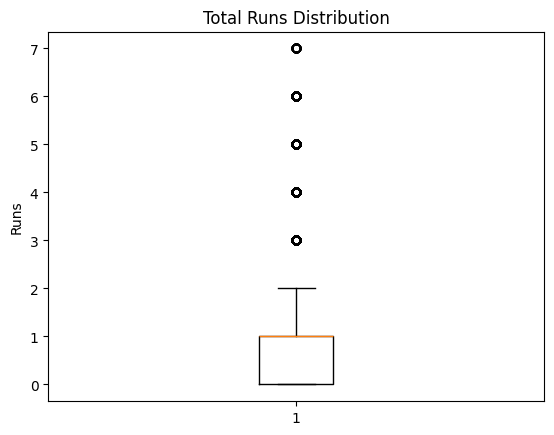

In [109]:
plt.boxplot(deliveries['total_runs'])
plt.title("Total Runs Distribution")
plt.ylabel("Runs")
plt.show()

#### Insight:
* Most deliveries resulted in 0 to 1 run.
* Scores above 2 runs per ball are less frequent and appear as outliers.
* Boundaries such as 4s and 6s contribute significantly to high-scoring deliveries.

#### 2.Histogram

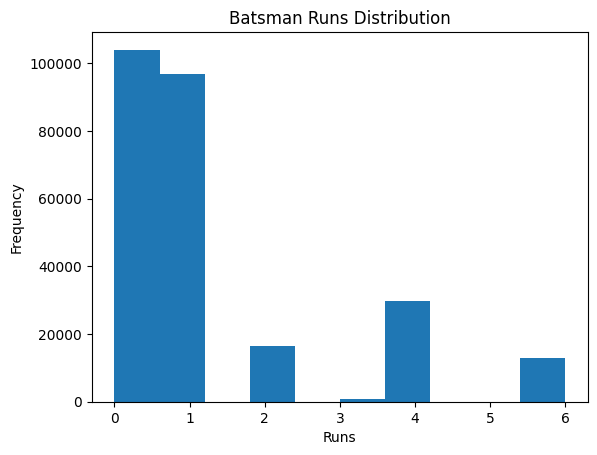

In [110]:
plt.hist(deliveries['batsman_runs'])
plt.title("Batsman Runs Distribution")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.show()

####Insight:
* The majority of balls resulted in 0 or 1 run.
* Singles dominate IPL scoring patterns.
* Boundaries (4s and 6s) occur less frequently but have a major impact on innings totals.

#### 3.Bar Chart

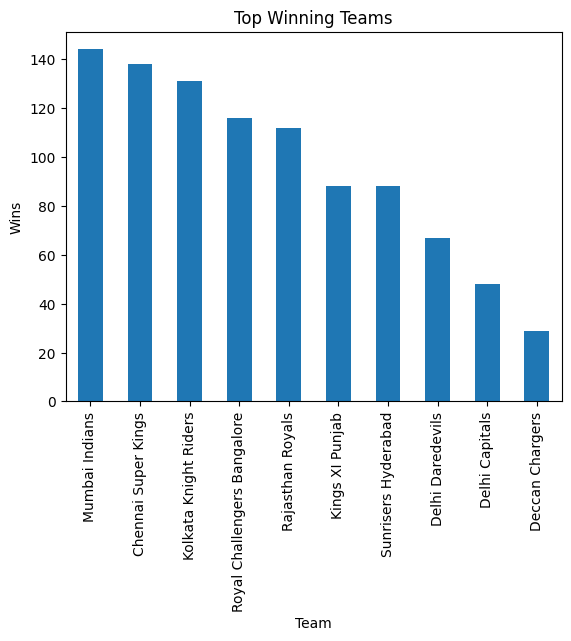

In [111]:
matches['winner'].value_counts().head(10).plot(kind="bar")
plt.title("Top Winning Teams")
plt.xlabel("Team")
plt.ylabel("Wins")
plt.show()

####Insight:
* Some teams have consistently won more matches than others.
* The chart highlights the most successful franchises in IPL history.
* Team performance varies significantly across seasons.
* Mumbai Indians and Chennai Super Kings are among the most successful teams with the highest number of wins.

#### 4.Scatter Plot

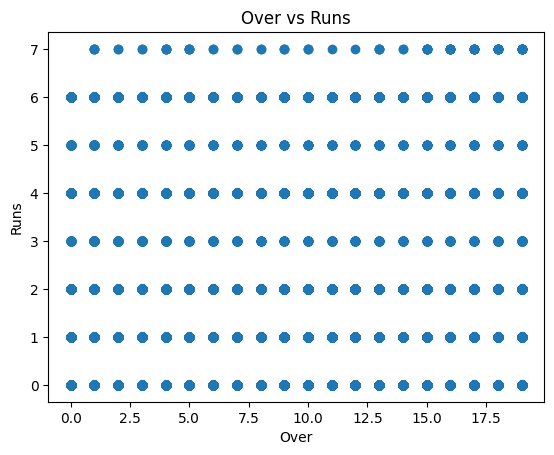

In [112]:
plt.scatter(deliveries['over'],deliveries['total_runs'])
plt.title("Over vs Runs")
plt.xlabel("Over")
plt.ylabel("Runs")
plt.show()

#### Insight:
* Runs are scored in every over of an innings.
* Higher scoring deliveries such as 4s and 6s are observed across different overs.
* The scoring pattern suggests teams maintain run-scoring opportunities throughout the innings.

#### 5.Groupby Chart

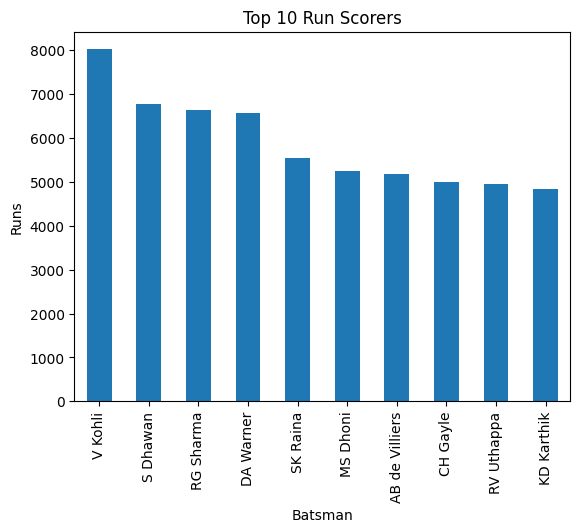

In [113]:
top_batsman = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)
top_batsman.plot(kind = "bar")
plt.title("Top 10 Run Scorers")
plt.xlabel("Batsman")
plt.ylabel("Runs")
plt.show()

#### Insight:

- The group-by analysis shows the total runs scored by winning teams across different IPL seasons.
- Teams that scored higher total runs generally achieved more match victories.
- Chennai Super Kings, Kings XI Punjab, and Delhi Daredevils were among the top-performing teams in the displayed season based on total runs scored.
- The results indicate that strong batting performances play an important role in determining match outcomes.
- This analysis helps identify successful teams and understand their scoring patterns over different seasons.

## Final Insights and Findings
###1. Data Quality and Cleaning
* The dataset contained missing values in columns such as result_margin, target_runs, and target_overs, which were handled using appropriate statistical techniques.
* Duplicate records were checked and removed to improve data consistency.
* The dataset was validated after cleaning to ensure it was ready for analysis.
### 2. Match Trends
* Certain teams consistently recorded a higher number of victories, indicating stronger long-term performance in the tournament.
* Team performance varied across seasons, highlighting changes in squad strength, strategy, and player contributions.
### 3. Scoring Distribution
* Most deliveries resulted in 0 or 1 run, showing that singles and dot balls form the majority of scoring events in T20 cricket.
* Boundaries such as fours and sixes occurred less frequently but contributed significantly to total team scores.
###4. Outlier Analysis
* A large number of outliers were detected in total_runs and extra_runs.
* These values represent genuine cricket events such as boundaries, wides, no-balls, and high-scoring deliveries rather than data errors, so they were retained for analysis.
###5. Over-wise Scoring Pattern
* Runs were scored throughout all overs of the innings.
* High-scoring deliveries, including boundaries, occurred in different phases of the match, indicating that teams attempted to maintain scoring momentum across the innings.
###6. Overall Conclusion
* The IPL dataset demonstrates clear patterns in team performance, scoring behavior, and match outcomes.
* Data cleaning, exploratory analysis, SQL querying, and visualization together provided meaningful insights into batting trends and team success across IPL seasons.